In [1]:
import particles
from sir_PMCMC import ChainBinomialModel
from sir_PMCMC import ScalarStructDist
from sir_PMCMC import custom_mom
import multiprocess as mp
import numpy as np
import pandas as pd
import seaborn as sb
import time
import pickle
import statistics

from particles import distributions as dists
from particles import state_space_models as ssm
from particles.collectors import Moments
from particles import mcmc
from collections import OrderedDict
from particles import collectors as col
from matplotlib import pyplot as plt
from SIR_Model import model, x, y


In [2]:
# Prior distributions for Parameters
prior_dict_test = {'beta': dists.Gamma(a = 4.5, b=10), # where scale = 1/b
              'gamma': dists.Gamma(a = 8, b = 100)}  # Uniform distribution because the prior is uninformative

my_prior_test = ScalarStructDist(prior_dict_test)      # need this because 'dict' object has no attribute 'dtype' but StructDist does

Text(0.5, 0, 'sigma')

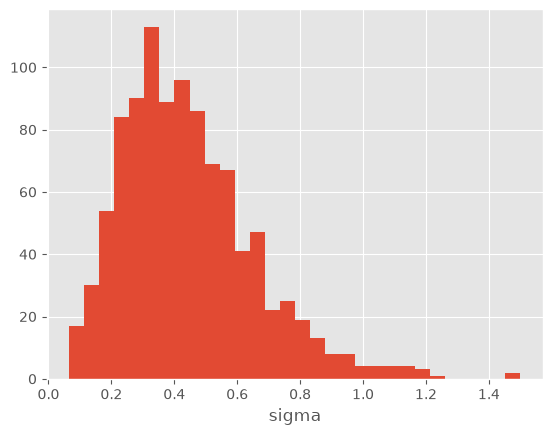

In [3]:
theta = my_prior_test.rvs(size=1000)  # sample 500 theta-parameters

plt.style.use('ggplot')
plt.hist(theta['beta'], 30);
plt.xlabel('sigma')



# Plot SIR epidemic progression in Matplotlib

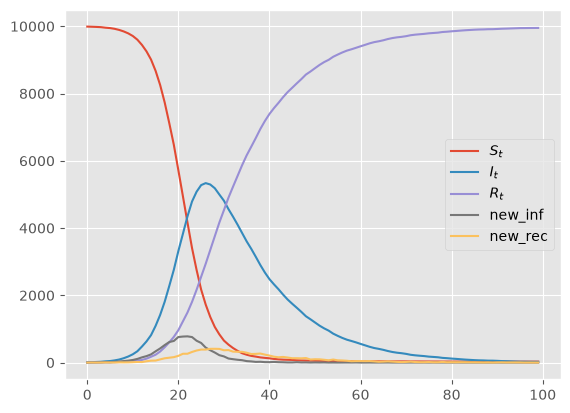

In [4]:
# Plot count of new infections, new recoveries, susceptibles, infectious, and removed
plt.style.use('ggplot')
plt.plot([xt['S'] for xt in x], label=r'$S_t$')
plt.plot([xt['I'] for xt in x], label=r'$I_t$')
plt.plot([xt['R'] for xt in x], label=r'$R_t$')
plt.plot([xt['new_inf'] for xt in x], label='new_inf')
plt.plot([xt['new_rec'] for xt in x], label='new_rec')
plt.legend()

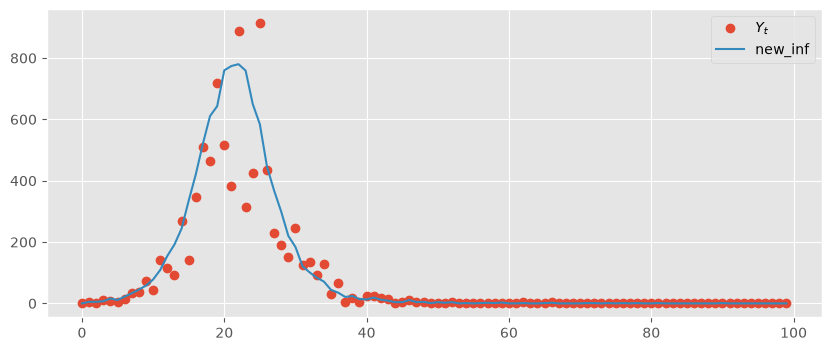

In [5]:
# Plot the observation model
plt.style.use('ggplot')
plt.figure(figsize=(10,4))
plt.plot(y, label=r'$Y_t$', linestyle='', marker='o')
plt.plot([xt['new_inf'] for xt in x], label='new_inf')

plt.legend()

# DataFrames & csv files

In [6]:
simulation_df = pd.DataFrame(np.concatenate(x))
print(simulation_df)

    new_inf  new_rec       S     I       R
0       0.0      0.0  9990.0  10.0     0.0
1       5.0      2.0  9985.0  13.0     2.0
2       5.0      0.0  9980.0  18.0     2.0
3       7.0      1.0  9973.0  24.0     3.0
4      16.0      3.0  9957.0  37.0     6.0
..      ...      ...     ...   ...     ...
95      0.0      5.0    29.0  26.0  9945.0
96      0.0      1.0    29.0  25.0  9946.0
97      0.0      2.0    29.0  23.0  9948.0
98      0.0      1.0    29.0  22.0  9949.0
99      0.0      1.0    29.0  21.0  9950.0

[100 rows x 5 columns]


In [7]:
# Isolate observations (noisy) for use in ABC-SMC
observation_df = pd.DataFrame(np.concatenate(y))
observation_df = observation_df.rename(columns={0: 'observations'})
print(observation_df)

    observations
0              0
1              5
2              2
3             11
4              8
..           ...
95             0
96             0
97             0
98             0
99             0

[100 rows x 1 columns]


# Sequential Monte Carlo

In [18]:
fk = ssm.Bootstrap(ssm=model, data=y)
alg = particles.SMC(fk=fk, 
                    N=200,
                    resampling = 'systematic', 
                    verbose=True,
                    collect=[Moments(mom_func = custom_mom)],
                    store_history=True)
alg.run()

t=0: resample:False, ESS (end of iter)=200.00
t=1: resample:False, ESS (end of iter)=180.72
t=2: resample:False, ESS (end of iter)=134.06
t=3: resample:False, ESS (end of iter)=112.24
t=4: resample:False, ESS (end of iter)=101.32
t=5: resample:False, ESS (end of iter)=73.13
t=6: resample:True, ESS (end of iter)=187.86
t=7: resample:False, ESS (end of iter)=167.08
t=8: resample:False, ESS (end of iter)=157.32
t=9: resample:False, ESS (end of iter)=130.71
t=10: resample:False, ESS (end of iter)=131.06
t=11: resample:False, ESS (end of iter)=109.66
t=12: resample:False, ESS (end of iter)=108.29
t=13: resample:False, ESS (end of iter)=107.41
t=14: resample:False, ESS (end of iter)=102.34
t=15: resample:False, ESS (end of iter)=97.54
t=16: resample:True, ESS (end of iter)=199.44
t=17: resample:False, ESS (end of iter)=197.67
t=18: resample:False, ESS (end of iter)=197.45
t=19: resample:False, ESS (end of iter)=196.50
t=20: resample:False, ESS (end of iter)=196.32
t=21: resample:False, ESS (

In [19]:
print(alg.W)

[0.00835263 0.001349   0.00835263 0.00335674 0.00335674 0.001349
 0.00335674 0.00835263 0.00335674 0.00835263 0.00335674 0.001349
 0.00335674 0.00835263 0.00335674 0.00835263 0.00835263 0.00835263
 0.00335674 0.00335674 0.00062413 0.00835263 0.00835263 0.00835263
 0.00155304 0.00335674 0.00835263 0.00835263 0.00335674 0.00835263
 0.00835263 0.001349   0.00835263 0.00835263 0.001349   0.00335674
 0.00835263 0.00835263 0.001349   0.00835263 0.00835263 0.00054213
 0.00835263 0.001349   0.00835263 0.00335674 0.00835263 0.00335674
 0.00335674 0.00835263 0.00835263 0.00835263 0.00335674 0.001349
 0.00835263 0.001349   0.00835263 0.00335674 0.00835263 0.00021787
 0.00835263 0.00335674 0.00335674 0.00835263 0.00835263 0.00835263
 0.00062413 0.001349   0.00835263 0.00335674 0.00335674 0.00335674
 0.00335674 0.00835263 0.00335674 0.00335674 0.00835263 0.00335674
 0.00835263 0.001349   0.00335674 0.00835263 0.00835263 0.00335674
 0.00335674 0.00335674 0.001349   0.001349   0.00335674 0.00335674
 

In [10]:
weights = alg.W
ess = 1 / np.sum(weights**2)
print(ess)

83.14115136139857


## Moments

In [11]:
# Create a list of 'I' means 
I_means = []
for a in range(100):
    I = alg.summaries.moments[a]['mean'][3]
    I_means.append(I)

print(I_means)
print(len(I_means))

[9.999999999999982, 14.381475819949564, 17.910016887970702, 26.204235152299823, 34.32930416034276, 40.886579768879805, 54.30338277740506, 80.26350586510725, 110.855808888622, 162.51650356887757, 212.94315611265304, 307.2266305832351, 410.66601697183575, 532.154637978163, 726.2392398126999, 928.9224607466015, 1236.9906528283511, 1611.9085829291737, 2035.469978488847, 2538.168012443457, 3059.014871486655, 3592.5562320769504, 4110.319867154825, 4573.420151857092, 4929.716759659017, 5137.09802081947, 5253.648828305011, 5255.740680669391, 5163.856375238795, 5001.902774969094, 4813.54082784884, 4582.887713942384, 4351.195508738939, 4105.962527049466, 3884.5073948671456, 3623.064003832429, 3391.5307544771335, 3148.5908586438863, 2926.0373962538224, 2707.6025257335054, 2517.0396409838395, 2345.1215012325893, 2178.2199322551774, 2024.4520021317717, 1865.1283330274491, 1726.6023538793122, 1600.5241195561878, 1481.8753185031092, 1370.2549797833892, 1267.85448517096, 1169.6857966437353, 1077.54269

Text(0, 0.5, 'Mean "I"')

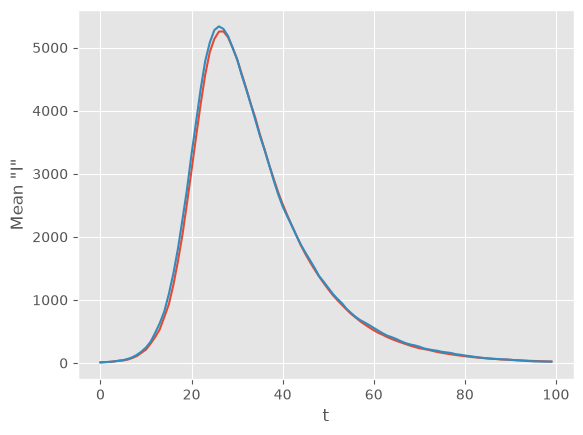

In [12]:
plt.plot(I_means)
plt.plot([xt['I'] for xt in x], label=r'$I_t$')
plt.xlabel('t')
plt.ylabel('Mean "I"')

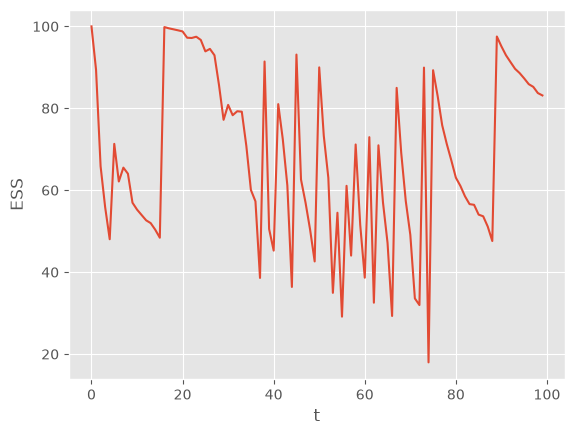

In [13]:
plt.plot(alg.summaries.ESSs)
plt.xlabel('t')
plt.ylabel('ESS');

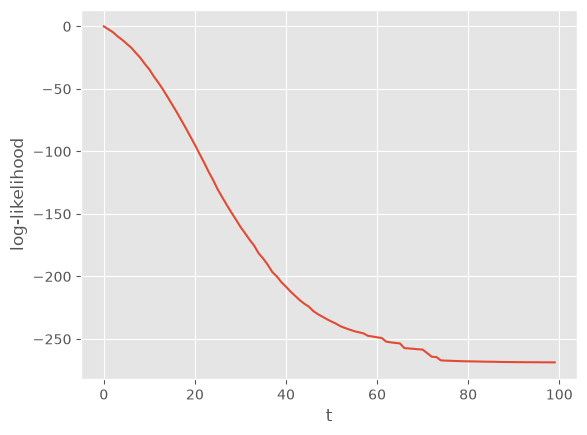

In [14]:
plt.plot(alg.summaries.logLts)
plt.xlabel('t')
plt.ylabel('log-likelihood');

# PMCMC Algorithm

Time taken: 194.50 seconds for four independent chains (on 4 separate cores); 100 particles and 7500 iterations

In [15]:
# Run 4 independent PMCMC chains
path_multi = '/Users/gabriellebouvier/SIR_Model/pmmh_chain_multi.pkl'
with open(path_multi, 'rb') as output_multi:
    chain_multi = pickle.load(output_multi)


FileNotFoundError: [Errno 2] No such file or directory: '/Users/gabriellebouvier/SIR_Model/pmmh_chain_multi.pkl'

In [ ]:
# Posterior distributions for the parameters in each chain
beta_chain_0 = [p['theta']['beta'] for p in chain_multi[0].chain]
gamma_chain_0 = [p['theta']['gamma'] for p in chain_multi[0].chain]

beta_chain_1 = [p['theta']['beta'] for p in chain_multi[1].chain]
gamma_chain_1 = [p['theta']['gamma'] for p in chain_multi[1].chain]

beta_chain_2 = [p['theta']['beta'] for p in chain_multi[2].chain]
gamma_chain_2 = [p['theta']['gamma'] for p in chain_multi[2].chain]

beta_chain_3 = [p['theta']['beta'] for p in chain_multi[3].chain]
gamma_chain_3 = [p['theta']['gamma'] for p in chain_multi[3].chain]


## Plot Marginals

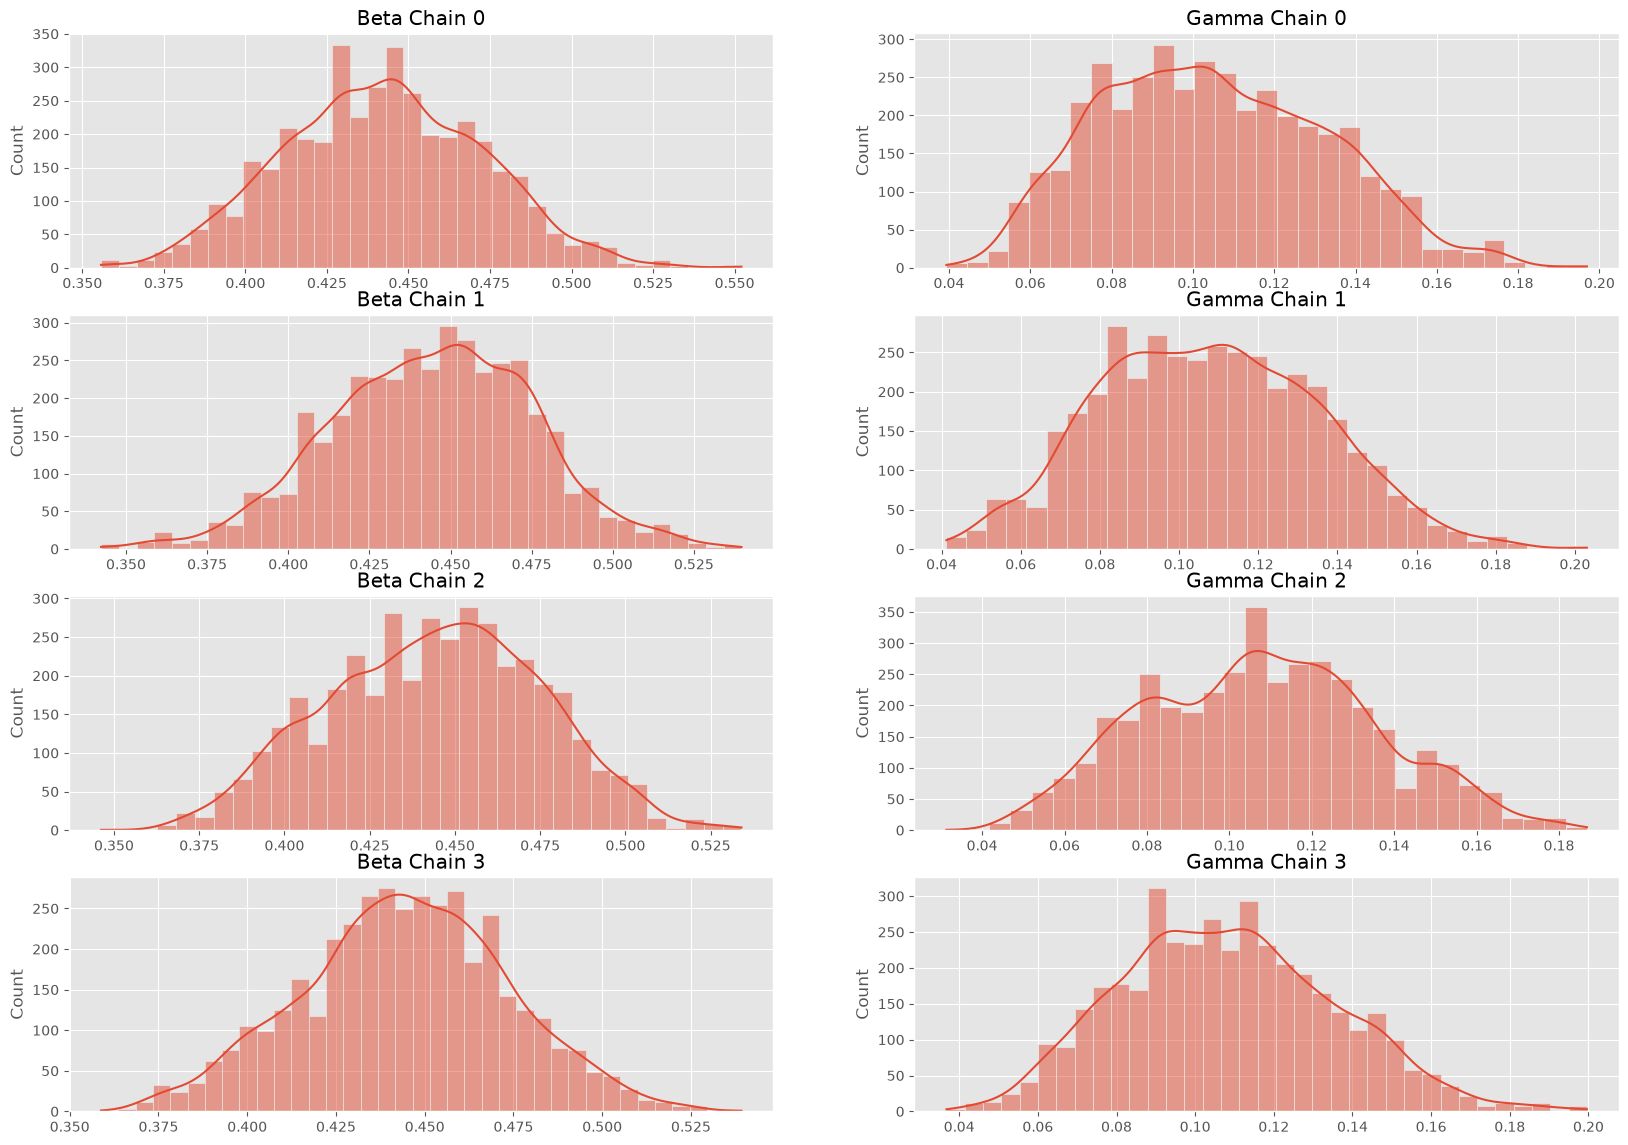

In [ ]:
burnin = 1000
fig, axes = plt.subplots(4,2)
sb.histplot(beta_chain_0[burnin:], ax=axes[0,0], kde=True).set(title='Beta Chain 0')
sb.histplot(gamma_chain_0[burnin:], ax=axes[0,1], kde=True).set(title='Gamma Chain 0')
sb.histplot(beta_chain_1[burnin:], ax=axes[1,0], kde=True).set(title='Beta Chain 1')
sb.histplot(gamma_chain_1[burnin:], ax=axes[1,1], kde=True).set(title='Gamma Chain 1')
sb.histplot(beta_chain_2[burnin:], ax=axes[2,0], kde=True).set(title='Beta Chain 2')
sb.histplot(gamma_chain_2[burnin:], ax=axes[2,1], kde=True).set(title='Gamma Chain 2')
sb.histplot(beta_chain_3[burnin:], ax=axes[3,0], kde=True).set(title='Beta Chain 3')
sb.histplot(gamma_chain_3[burnin:], ax=axes[3,1], kde=True).set(title='Gamma Chain 3')
fig.set_figheight(14)
fig.set_figwidth(20)

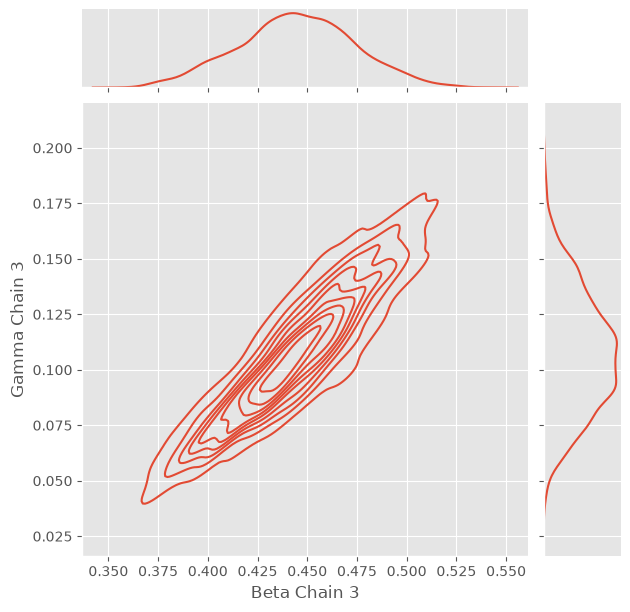

In [ ]:
beta_density_3 = beta_chain_3[burnin:]
gamma_density_3 = gamma_chain_3[burnin:]
sb.jointplot(x = beta_density_3, y = gamma_density_3, kind = 'kde')
plt.xlabel('Beta Chain 3')
plt.ylabel('Gamma Chain 3')
plt.show()

## Trace Plot

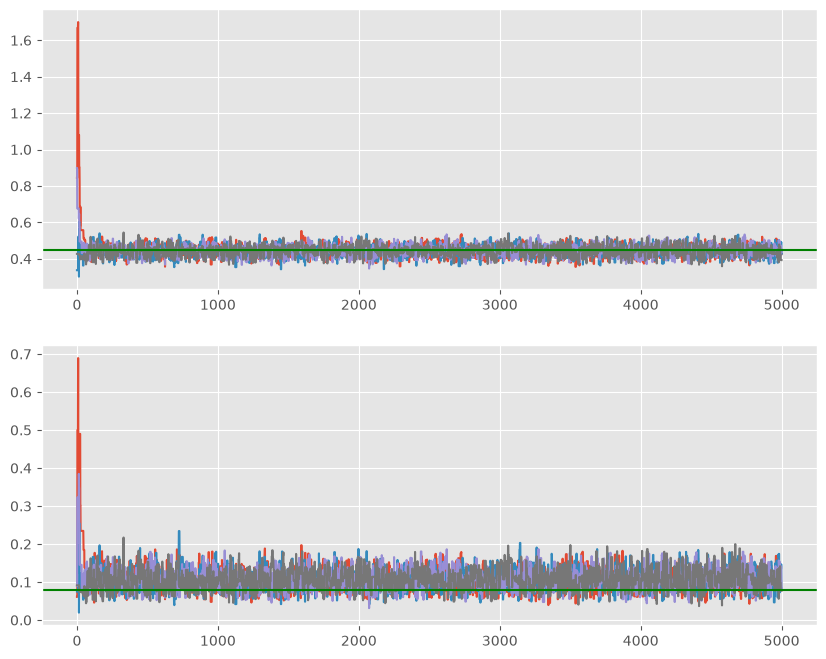

In [ ]:
fig, axes = plt.subplots(2,1)
axes[0].plot(beta_chain_0)
axes[0].plot(beta_chain_1)
axes[0].plot(beta_chain_2)
axes[0].plot(beta_chain_3)
axes[1].plot(gamma_chain_0)
axes[1].plot(gamma_chain_1)
axes[1].plot(gamma_chain_2)
axes[1].plot(gamma_chain_3)
fig.set_figheight(8)
fig.set_figwidth(10)
axes[0].axhline(y = 0.45, color='green')
axes[1].axhline(y = 0.08, color='green')

## Posterior Means

In [ ]:
pmcmc_0_beta = np.array(beta_chain_0[burnin:])
pmcmc_1_beta = np.array(beta_chain_1[burnin:])
pmcmc_2_beta = np.array(beta_chain_2[burnin:])
pmcmc_3_beta = np.array(beta_chain_3[burnin:])

pmcmc_0_gamma = np.array(gamma_chain_0[burnin:])
pmcmc_1_gamma = np.array(gamma_chain_1[burnin:])
pmcmc_2_gamma = np.array(gamma_chain_2[burnin:])
pmcmc_3_gamma = np.array(gamma_chain_3[burnin:])

np.savez("pmcmc_posteriors.npz", arr0 = pmcmc_0_beta, arr1 = pmcmc_1_beta, arr2 = pmcmc_2_beta, arr3 = pmcmc_3_beta, arr4 = pmcmc_0_gamma, arr5 = pmcmc_1_gamma, arr6 = pmcmc_2_gamma, arr7 = pmcmc_3_gamma)

In [ ]:
beta_chain_0_mean = statistics.mean(beta_chain_0[burnin:])
gamma_chain_0_mean = statistics.mean(gamma_chain_0[burnin:])
beta_chain_1_mean = statistics.mean(beta_chain_1[burnin:])
gamma_chain_1_mean = statistics.mean(gamma_chain_1[burnin:])
beta_chain_2_mean = statistics.mean(beta_chain_2[burnin:])
gamma_chain_2_mean = statistics.mean(gamma_chain_2[burnin:])
beta_chain_3_mean = statistics.mean(beta_chain_3[burnin:])
gamma_chain_3_mean = statistics.mean(gamma_chain_3[burnin:])

print(f'Beta posterior mean for chain 0: {beta_chain_0_mean : .4f}')
print(f'Beta posterior mean for chain 1: {beta_chain_1_mean : .4f}')
print(f'Beta posterior mean for chain 2: {beta_chain_2_mean : .4f}')
print(f'Beta posterior mean for chain 3: {beta_chain_3_mean : .4f}')
print("--------------------------------------------------------")
print(f'Gamma posterior mean for chain 0: {gamma_chain_0_mean : .4f}')
print(f'Gamma posterior mean for chain 1: {gamma_chain_1_mean : .4f}')
print(f'Gamma posterior mean for chain 2: {gamma_chain_2_mean : .4f}')
print(f'Gamma posterior mean for chain 3: {gamma_chain_3_mean : .4f}')


Beta posterior mean for chain 0:  0.4421
Beta posterior mean for chain 1:  0.4444
Beta posterior mean for chain 2:  0.4440
Beta posterior mean for chain 3:  0.4446
--------------------------------------------------------
Gamma posterior mean for chain 0:  0.1051
Gamma posterior mean for chain 1:  0.1076
Gamma posterior mean for chain 2:  0.1075
Gamma posterior mean for chain 3:  0.1081


## Bias

In [ ]:
print(f'Beta posterior mean for chain 0: {beta_chain_0_mean - 0.45: .4f}')
print(f'Beta posterior mean for chain 1: {beta_chain_1_mean - 0.45: .4f}')
print(f'Beta posterior mean for chain 2: {beta_chain_2_mean - 0.45: .4f}')
print(f'Beta posterior mean for chain 3: {beta_chain_3_mean - 0.45: .4f}')
print("--------------------------------------------------------")
print(f'Gamma posterior mean for chain 0: {gamma_chain_0_mean - 0.08: .4f}')
print(f'Gamma posterior mean for chain 1: {gamma_chain_1_mean - 0.08: .4f}')
print(f'Gamma posterior mean for chain 2: {gamma_chain_2_mean - 0.08: .4f}')
print(f'Gamma posterior mean for chain 3: {gamma_chain_3_mean - 0.08: .4f}')

Beta posterior mean for chain 0: -0.0079
Beta posterior mean for chain 1: -0.0056
Beta posterior mean for chain 2: -0.0060
Beta posterior mean for chain 3: -0.0054
--------------------------------------------------------
Gamma posterior mean for chain 0:  0.0251
Gamma posterior mean for chain 1:  0.0276
Gamma posterior mean for chain 2:  0.0275
Gamma posterior mean for chain 3:  0.0281


## Error (MSE)

In [ ]:
beta_mse_0 = np.square(np.subtract(0.45, beta_chain_0_mean)).mean()
beta_mse_1 = np.square(np.subtract(0.45, beta_chain_1_mean)).mean()
beta_mse_2 = np.square(np.subtract(0.45, beta_chain_2_mean)).mean()
beta_mse_3 = np.square(np.subtract(0.45, beta_chain_3_mean)).mean()
gamma_mse_0 = np.square(np.subtract(0.08, gamma_chain_0_mean)).mean()
gamma_mse_1 = np.square(np.subtract(0.08, gamma_chain_1_mean)).mean()
gamma_mse_2 = np.square(np.subtract(0.08, gamma_chain_2_mean)).mean()
gamma_mse_3 = np.square(np.subtract(0.08, gamma_chain_3_mean)).mean()


print(f"The MSE of the posterior mean estimate of beta chain 0 is {beta_mse_0}")
print(f"The MSE of the posterior mean estimate of beta chain 1 is {beta_mse_1}")
print(f"The MSE of the posterior mean estimate of beta chain 2 is {beta_mse_2}")
print(f"The MSE of the posterior mean estimate of beta chain 3 is {beta_mse_3}")
print("-----------------------------------------------------------------------")
print(f"The MSE of the posterior mean estimate of gamma chain 0 is {gamma_mse_0 : .5f}")
print(f"The MSE of the posterior mean estimate of gamma chain 1 is {gamma_mse_1 : .5f}")
print(f"The MSE of the posterior mean estimate of gamma chain 2 is {gamma_mse_2 : .5f}")
print(f"The MSE of the posterior mean estimate of gamma chain 3 is {gamma_mse_3 : .5f}")

The MSE of the posterior mean estimate of beta chain 0 is 6.209944675279356e-05
The MSE of the posterior mean estimate of beta chain 1 is 3.141105125485786e-05
The MSE of the posterior mean estimate of beta chain 2 is 3.549817602209489e-05
The MSE of the posterior mean estimate of beta chain 3 is 2.9344237335624463e-05
-----------------------------------------------------------------------
The MSE of the posterior mean estimate of gamma chain 0 is  0.00063
The MSE of the posterior mean estimate of gamma chain 1 is  0.00076
The MSE of the posterior mean estimate of gamma chain 2 is  0.00076
The MSE of the posterior mean estimate of gamma chain 3 is  0.00079


# Posterior Variance

In [ ]:
beta_chain_0_variance = statistics.variance(beta_chain_0[burnin:])
gamma_chain_0_variance = statistics.variance(gamma_chain_0[burnin:])
beta_chain_1_variance = statistics.variance(beta_chain_1[burnin:])
gamma_chain_1_variance = statistics.variance(gamma_chain_1[burnin:])
beta_chain_2_variance = statistics.variance(beta_chain_2[burnin:])
gamma_chain_2_variance = statistics.variance(gamma_chain_2[burnin:])
beta_chain_3_variance = statistics.variance(beta_chain_3[burnin:])
gamma_chain_3_variance = statistics.variance(gamma_chain_3[burnin:])

print(beta_chain_0_variance)
print(beta_chain_1_variance)
print(beta_chain_2_variance)
print(beta_chain_3_variance)
print("---------------------")
print(gamma_chain_0_variance)
print(gamma_chain_1_variance)
print(gamma_chain_2_variance)
print(gamma_chain_3_variance)

0.0009260956206107846
0.0009731732092157269
0.0009579909800685404
0.0008470210706702028
---------------------
0.0007649571989015811
0.0007649932433503456
0.0007776900067766235
0.0007470376899024793


In [ ]:
print(dir(chain_multi[0]))
print("--------------------------")
print(dir(chain_multi[0].chain))

['L', 'Nx', '__class__', '__delattr__', '__dict__', '__dir__', '__doc__', '__eq__', '__format__', '__ge__', '__getattribute__', '__getstate__', '__gt__', '__hash__', '__init__', '__init_subclass__', '__le__', '__lt__', '__module__', '__ne__', '__new__', '__reduce__', '__reduce_ex__', '__repr__', '__setattr__', '__sizeof__', '__str__', '__subclasshook__', '__weakref__', 'acc_rate', 'adaptive', 'alg_instance', 'arr', 'chain', 'compute_post', 'cov_tracker', 'cpu_time', 'data', 'dim', 'fk_cls', 'mean_sq_jump_dist', 'nacc', 'niter', 'print_progress', 'prior', 'prop', 'prop_arr', 'run', 'scale', 'smc_cls', 'smc_options', 'ssm_cls', 'step', 'step0', 'theta0', 'verbose']
--------------------------
['N', '__class__', '__delattr__', '__dict__', '__dir__', '__doc__', '__eq__', '__format__', '__ge__', '__getattribute__', '__getitem__', '__getstate__', '__gt__', '__hash__', '__init__', '__init_subclass__', '__le__', '__lt__', '__module__', '__ne__', '__new__', '__reduce__', '__reduce_ex__', '__repr

In [ ]:

print(chain_multi[0].cpu_time)
print(chain_multi[1].cpu_time)
print(chain_multi[2].cpu_time)
print(chain_multi[3].cpu_time)

120.530688208004
120.98521291598445
120.46143112500431
121.10194029199192
